**Phase 1: One-Shot Learning & Baseline Comparison**
* Implement Bandits and Baseline ML models.
* Perform baseline comparison using Linear Regression, Logistic Regression, and Decision Trees.


**Phase 2: Step-wise Training**
* Implement Active Learning (AL) and Bandits (if possible).
* Generate plots based on the total number of fraud rules specifically for the AL component.


**Phase 3: Active Learning Implementation & Optimization**
* Implement XGBoost and Bandit-based Active Learning using the following strategies: Uncertainty, Cost-weighted, Expected cost reduction, and Diversity.
* If default loss functions are ineffective, implement and test custom loss functions.


**Phase 4: Validation & Visualization**
* Generate decreasing plots for financial costs and increasing plots for recall.
* Include validation plots within the Active Learning section.
* Evaluate data quality: If the Bandit implementation yields proper F1 score plots, the generated data is considered sufficient.

## Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
!apt-get install git
!git clone https://github.com/Nikshay-Jain/DDP.git /content/drive/MyDrive/

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
git is already the newest version (1:2.34.1-1ubuntu1.15).
0 upgraded, 0 newly installed, 0 to remove and 1 not upgraded.
Cloning into '/content/drive/MyDrive/DDP'...
remote: Enumerating objects: 78, done.
remote: Counting objects: 100% (5/5), done.
remote: Compressing objects: 100% (3/3), done.
remote: Total 78 (delta 4), reused 2 (delta 2), pack-reused 73 (from 1)
Receiving objects: 100% (78/78), 88.59 MiB | 13.51 MiB/s, done.
Resolving deltas: 100% (31/31), done.
Updating files: 100% (20/20), done.


In [14]:
import zipfile, os, shutil
import pandas as pd

zip_path = "/content/drive/MyDrive/DDP/data_5L_new.zip"

extract_dir = "/content/extracted_zip"
with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall(extract_dir)

csv_file = None
for file in os.listdir(extract_dir):
    if file.endswith(".csv"):
        csv_file = os.path.join(extract_dir, file)
        break
if csv_file is None:
    raise FileNotFoundError("No CSV file found inside the ZIP.")

df = pd.read_csv(csv_file)
shutil.rmtree(extract_dir)
print("CSV loaded successfully!")

CSV loaded successfully!


In [15]:
df

,policy_no,policy_product,cust_occupation,tier,tier_premium_amt,occupants_count,paying_guest_no,business_use,unoccupied_days,unoccupied_reason,...,fire_safety_systems,security_systems,crime_rate,urban_rural,no_of_claims_5yr,premium_payment_behaviour,property_market_value,short_term_letting,fraud_probability,fraud_label
0,100000,Combined,skilled_worker,1,166.58,4,0,N,0,NaN,...,0,0,3,urban,0,74,880000,0,0.073655,0
1,100001,Combined,skilled_worker,2,342.37,2,0,N,0,NaN,...,1,1,1,rural,0,82,890000,0,0.066178,0
2,100002,Buildings,skilled_worker,2,325.97,1,0,N,30,NaN,...,0,0,3,urban,0,83,320000,0,0.087979,0
3,100003,Landlord,retired,1,160.16,6,0,N,0,NaN,...,0,1,5,urban,0,86,390000,0,0.062205,0
4,100004,Combined,professional,1,206.89,2,0,N,0,NaN,...,1,1,2,rural,0,71,590000,1,0.089477,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
499995,599995,Standard,white_collar,2,310.44,4,0,N,0,NaN,...,1,1,5,urban,0,84,610000,0,0.079920,0
499996,599996,Combined,retired,2,279.42,4,0,N,30,relocation,...,1,0,3,urban,2,92,300000,0,0.128952,0
499997,599997,Landlord,professional,2,336.84,4,0,N,0,NaN,...,0,1,1,urban,0,87,1060000,0,0.063849,0
499998,599998,Standard,white_collar,1,163.38,3,0,N,0,NaN,...,1,1,2,urban,1,76,390000,0,0.111040,0


## Baseline evaluation

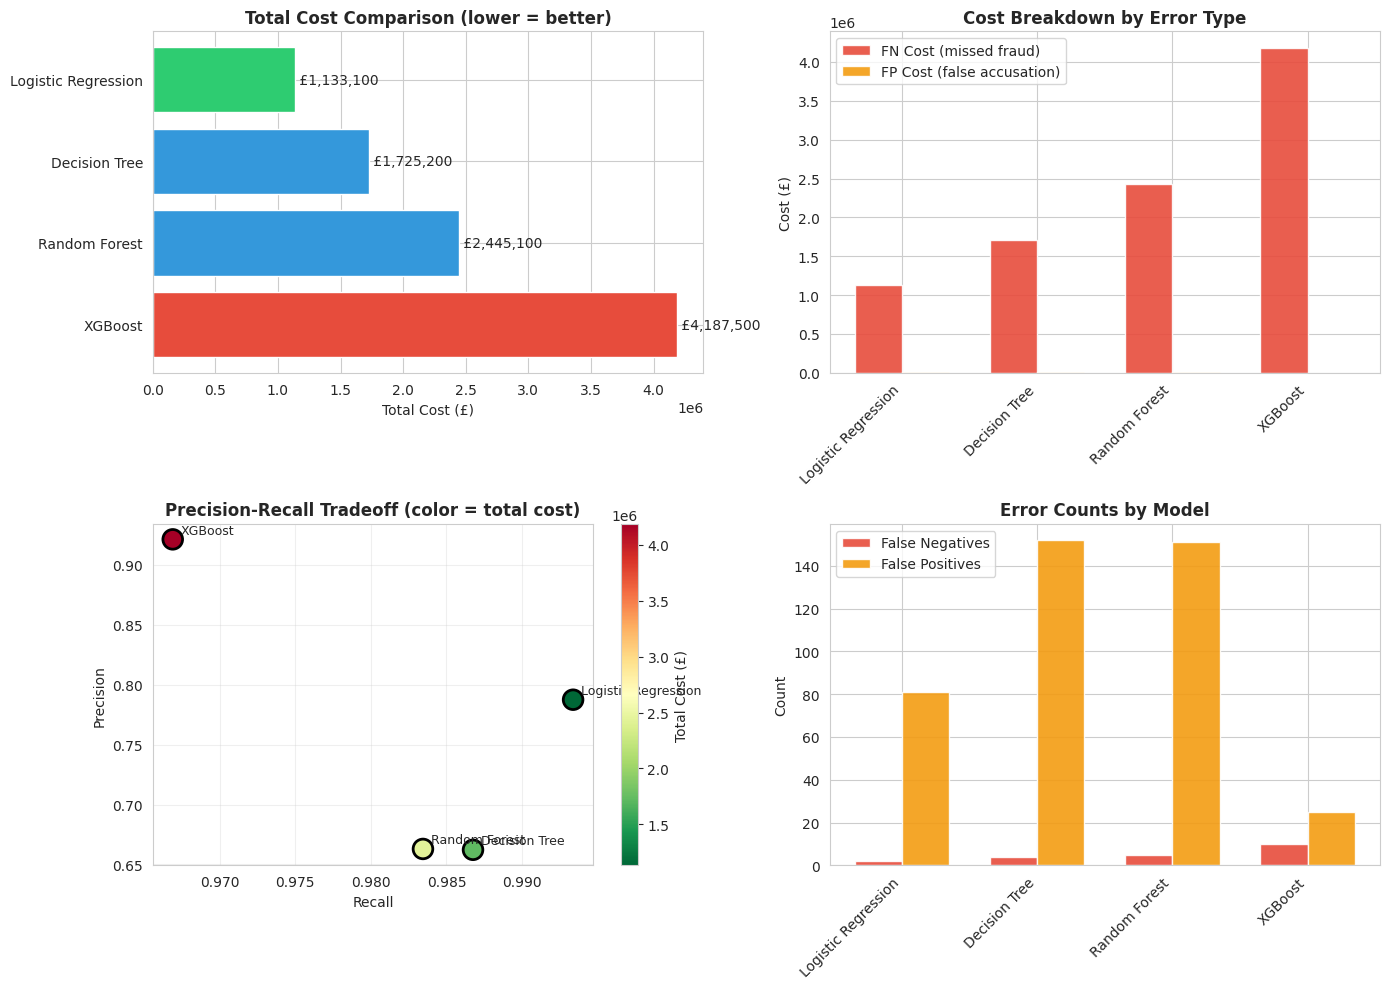

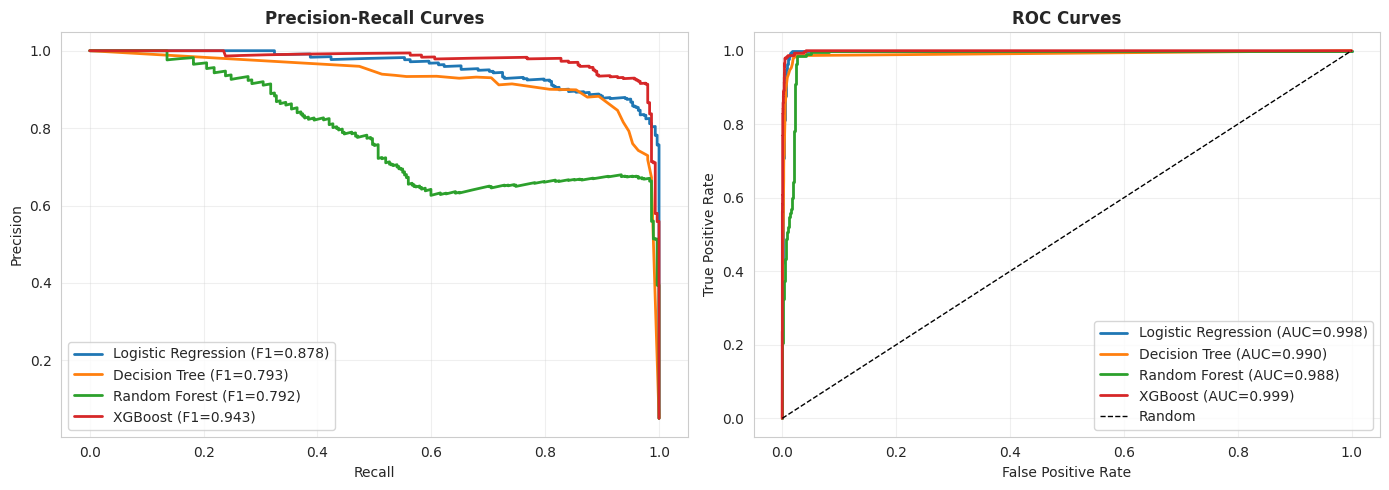

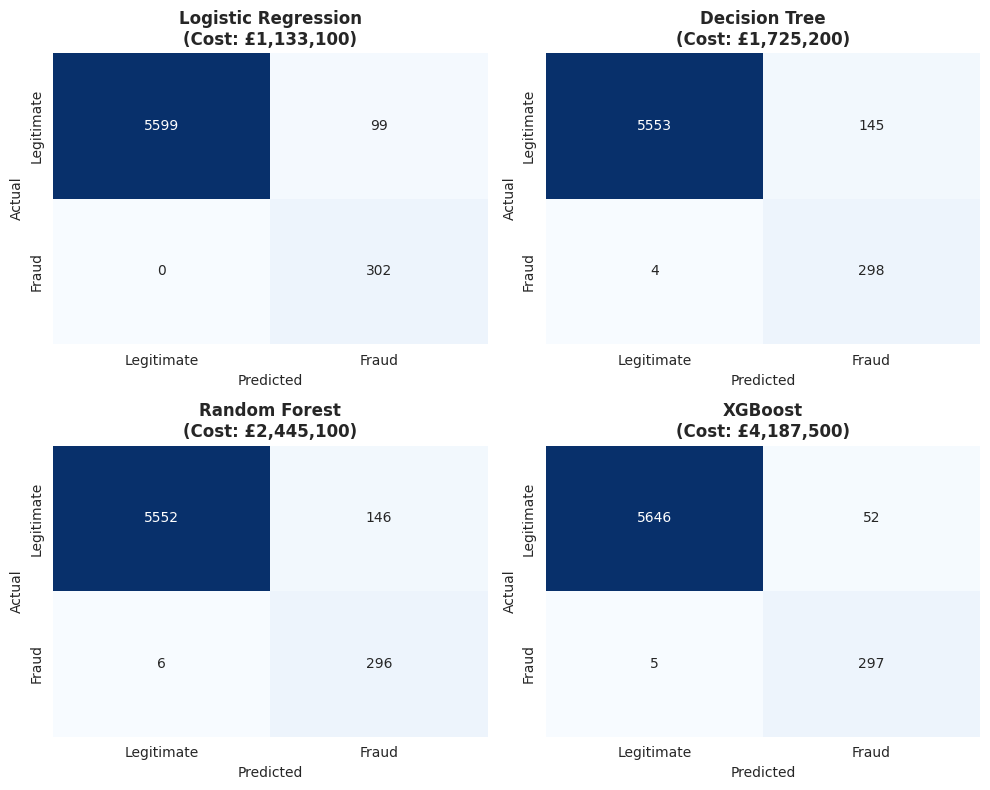

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support, roc_auc_score, precision_recall_curve, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from tqdm import tqdm
warnings.filterwarnings("ignore")
np.random.seed(42)

# ==================== STRATIFIED SAMPLING ====================
def stratified_sample(df, label_col='fraud_label', n=20000, random_state=42):
    """Stratified sampling with exact proportional allocation."""
    counts = df[label_col].value_counts().sort_index()
    total = counts.sum()

    if n >= total:
        return df.sample(frac=1.0, random_state=random_state).reset_index(drop=True)

    # Largest remainder method for exact allocation
    proportions = counts / total
    raw_alloc = proportions * n
    floor_alloc = np.floor(raw_alloc).astype(int)
    remainder = raw_alloc - floor_alloc
    allocated = floor_alloc.copy()

    remaining = int(n - floor_alloc.sum())
    if remaining > 0:
        idx_sort = np.argsort(-remainder.values)
        for i in range(remaining):
            allocated[idx_sort[i]] += 1

    sampled_parts = []
    for label, k in zip(counts.index, allocated):
        group = df[df[label_col] == label]
        sampled_parts.append(group.sample(n=min(k, len(group)), random_state=random_state))

    return pd.concat(sampled_parts, ignore_index=True).sample(frac=1.0, random_state=random_state).reset_index(drop=True)

# ==================== COST FUNCTIONS ====================
def calculate_costs(sum_insured, y_true, y_pred):
    """Instance-dependent cost: FN=90% of sum_insured, FP=£100."""
    sum_insured = np.asarray(sum_insured)
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    costs = np.zeros(len(y_true), dtype=float)

    fn_mask = (y_true == 1) & (y_pred == 0)
    fp_mask = (y_true == 0) & (y_pred == 1)

    costs[fn_mask] = sum_insured[fn_mask] * 0.90
    costs[fp_mask] = 100.0
    return costs

def evaluate_cost_sensitive(y_true, y_pred, sum_insured):
    """Comprehensive cost-sensitive evaluation."""
    costs = calculate_costs(sum_insured, y_true, y_pred)
    fn_mask = (y_true == 1) & (y_pred == 0)
    fp_mask = (y_true == 0) & (y_pred == 1)

    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='binary', zero_division=0)
    try:
        rocauc = roc_auc_score(y_true, y_pred)
    except:
        rocauc = np.nan

    return {
        'total_cost': float(costs.sum()),
        'fn_cost': float(costs[fn_mask].sum()),
        'fp_cost': float(costs[fp_mask].sum()),
        'fn_count': int(fn_mask.sum()),
        'fp_count': int(fp_mask.sum()),
        'tp': int(((y_true == 1) & (y_pred == 1)).sum()),
        'tn': int(((y_true == 0) & (y_pred == 0)).sum()),
        'precision': float(precision),
        'recall': float(recall),
        'f1': float(f1),
        'roc_auc': float(rocauc),
        'avg_cost_per_sample': float(costs.sum() / len(y_true))
    }

# ==================== FEATURE PREPARATION ====================
def prepare_data(df, label_col='fraud_label', sum_col='sum_insured'):
    """Prepare features with robust fallback."""
    feature_template = [
        'tier', 'tier_premium_amt', 'occupants_count', 'paying_guest_no',
        'unoccupied_days', 'sum_insured', 'premium_with_tax',
        'risk_premium_with_credit_score', 'risk_premium_without_credit_score',
        'additional_coverage_amount', 'tier_limit_value', 'item_limit_value',
        'main_part_premium', 'accidental_damage_premium', 'outbuildings_premium',
        'APR_FLAG', 'previous_insurance_buildings', 'previous_insurance_cne',
        'property_eligibility', 'contents_claim_counts', 'building_claim_count',
        'flood_risk', 'storm_risk', 'other_natural_calamities_risk',
        'property_age', 'no_of_rooms', 'plumbing_elec_age',
        'smart_home', 'fire_safety_systems', 'security_systems',
        'crime_rate', 'no_of_claims_5yr', 'premium_payment_behaviour',
        'property_market_value', 'short_term_letting'
    ]
    categorical_template = ['cust_occupation', 'owner_details', 'property_type',
                           'construction_material', 'roof_material', 'urban_rural', 'policy_product']

    feature_cols = [c for c in feature_template if c in df.columns and c != label_col]
    categorical_cols = [c for c in categorical_template if c in df.columns]

    if not feature_cols:
        numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
        feature_cols = [c for c in numeric_cols if c not in [label_col, sum_col]]

    df_enc = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
    all_features = [c for c in df_enc.columns if (c in feature_cols) or any(cat in c for cat in categorical_cols)]

    if not all_features:
        all_features = [c for c in df_enc.select_dtypes(include=[np.number]).columns if c not in [label_col, sum_col]]

    X = df_enc[all_features].fillna(0).values
    y = df_enc[label_col].values
    sum_insured = df_enc[sum_col].values if sum_col in df_enc.columns else np.zeros(len(df_enc))

    return X, y, sum_insured, all_features

# ==================== COST-SENSITIVE CLASSIFIER ====================
class CostSensitiveClassifier:
    """Wrapper that optimizes probability threshold for minimum cost."""
    def __init__(self, base_clf):
        self.clf = base_clf
        self.opt_threshold = 0.5

    def fit(self, X, y, sum_insured=None):
        self.clf.fit(X, y)

        if sum_insured is not None and hasattr(self.clf, "predict_proba"):
            proba = self.clf.predict_proba(X)[:, 1]
            thresholds = np.linspace(0.01, 0.99, 99)
            best_cost = np.inf
            best_t = 0.5

            for t in thresholds:
                y_pred = (proba >= t).astype(int)
                c = calculate_costs(sum_insured, y, y_pred).sum()
                if c < best_cost:
                    best_cost = c
                    best_t = t

            self.opt_threshold = best_t
        return self

    def predict(self, X):
        if hasattr(self.clf, "predict_proba"):
            proba = self.clf.predict_proba(X)[:, 1]
            return (proba >= self.opt_threshold).astype(int)
        return self.clf.predict(X)

    def predict_proba(self, X):
        if hasattr(self.clf, "predict_proba"):
            return self.clf.predict_proba(X)
        preds = self.clf.predict(X)
        return np.vstack([1-preds, preds]).T

# ==================== MAIN COMPARISON PIPELINE ====================
def compare_models(df, sample_size=20000, label_col='fraud_label', sum_col='sum_insured', random_state=42):
    """Train and compare cost-sensitive models."""

    # Stratified sampling
    df_sample = stratified_sample(df, label_col=label_col, n=sample_size, random_state=random_state)
    X, y, sum_ins, feature_names = prepare_data(df_sample, label_col=label_col, sum_col=sum_col)

    # Stratified train-test split
    X_train, X_test, y_train, y_test, sum_train, sum_test = train_test_split(
        X, y, sum_ins, test_size=0.30, random_state=random_state, stratify=y
    )

    # Standardization
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)

    results = {}
    probs_store = {}

    # Model configurations
    models = {
        'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=random_state),
        'Decision Tree': DecisionTreeClassifier(max_depth=10, min_samples_split=50, min_samples_leaf=20,
                                               class_weight='balanced', random_state=random_state),
        'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=10, min_samples_split=50,
                                               class_weight='balanced', random_state=random_state),
        'XGBoost': XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1,
                                scale_pos_weight=max(1, (y_train==0).sum() / max(1, (y_train==1).sum())),
                                random_state=random_state, use_label_encoder=False, eval_metric='logloss')
    }

    # Train and evaluate each model
    for name, base_clf in tqdm(models.items(), desc='Training ML Models'):
        clf = CostSensitiveClassifier(base_clf).fit(X_train_s, y_train, sum_train)
        y_pred = clf.predict(X_test_s)
        y_proba = clf.predict_proba(X_test_s)[:, 1]

        r = evaluate_cost_sensitive(y_test, y_pred, sum_test)
        r['proba'] = y_proba
        results[name] = r
        probs_store[name] = (y_test, y_proba)

    # Results DataFrame
    comp = pd.DataFrame([
        {
            'Model': m,
            'Total Cost (£)': results[m]['total_cost'],
            'FN Cost (£)': results[m]['fn_cost'],
            'FP Cost (£)': results[m]['fp_cost'],
            'FN Count': results[m]['fn_count'],
            'FP Count': results[m]['fp_count'],
            'TP': results[m]['tp'],
            'TN': results[m]['tn'],
            'Precision': results[m]['precision'],
            'Recall': results[m]['recall'],
            'F1': results[m]['f1'],
            'ROC AUC': results[m]['roc_auc'],
            'Avg Cost/Sample (£)': results[m]['avg_cost_per_sample']
        } for m in results.keys()
    ]).sort_values('Total Cost (£)')

    # ==================== VISUALIZATIONS ====================

    # Figure 1: Cost Analysis
    fig1, axes = plt.subplots(2, 2, figsize=(14, 10))

    # Total cost comparison
    ax = axes[0, 0]
    models_list = comp['Model']
    costs = comp['Total Cost (£)']
    colors = ['#2ecc71' if c == costs.min() else '#e74c3c' if c == costs.max() else '#3498db' for c in costs]
    ax.barh(models_list, costs, color=colors)
    ax.set_xlabel('Total Cost (£)')
    ax.set_title('Total Cost Comparison (lower = better)', fontweight='bold')
    ax.invert_yaxis()
    for i, v in enumerate(costs):
        ax.text(v, i, f' £{v:,.0f}', va='center')

    # Cost breakdown
    ax = axes[0, 1]
    x = np.arange(len(models_list))
    width = 0.35
    ax.bar(x - width/2, comp['FN Cost (£)'], width, label='FN Cost (missed fraud)', alpha=0.9, color='#e74c3c')
    ax.bar(x + width/2, comp['FP Cost (£)'], width, label='FP Cost (false accusation)', alpha=0.9, color='#f39c12')
    ax.set_xticks(x)
    ax.set_xticklabels(models_list, rotation=45, ha='right')
    ax.set_ylabel('Cost (£)')
    ax.set_title('Cost Breakdown by Error Type', fontweight='bold')
    ax.legend()

    # Precision-Recall tradeoff
    ax = axes[1, 0]
    sc = ax.scatter(comp['Recall'], comp['Precision'], s=200, c=comp['Total Cost (£)'],
                    cmap='RdYlGn_r', edgecolors='k', linewidths=2)
    for i, m in enumerate(models_list):
        ax.annotate(m, (comp['Recall'].iloc[i], comp['Precision'].iloc[i]),
                   xytext=(6, 4), textcoords='offset points', fontsize=9)
    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.set_title('Precision-Recall Tradeoff (color = total cost)', fontweight='bold')
    plt.colorbar(sc, ax=ax, label='Total Cost (£)')
    ax.grid(alpha=0.3)

    # Error counts
    ax = axes[1, 1]
    ax.bar(x - width/2, comp['FN Count'], width, label='False Negatives', alpha=0.9, color='#e74c3c')
    ax.bar(x + width/2, comp['FP Count'], width, label='False Positives', alpha=0.9, color='#f39c12')
    ax.set_xticks(x)
    ax.set_xticklabels(models_list, rotation=45, ha='right')
    ax.set_ylabel('Count')
    ax.set_title('Error Counts by Model', fontweight='bold')
    ax.legend()

    plt.tight_layout()
    plt.show()

    # Figure 2: PR and ROC Curves
    fig2, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Precision-Recall curves
    ax = axes[0]
    for m, (y_t, y_p) in probs_store.items():
        try:
            p, r, _ = precision_recall_curve(y_t, y_p)
            ax.plot(r, p, label=f"{m} (F1={results[m]['f1']:.3f})", linewidth=2)
        except:
            continue
    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.set_title('Precision-Recall Curves', fontweight='bold')
    ax.legend()
    ax.grid(alpha=0.3)

    # ROC curves
    ax = axes[1]
    for m, (y_t, y_p) in probs_store.items():
        try:
            fpr, tpr, _ = roc_curve(y_t, y_p)
            roc_auc = auc(fpr, tpr)
            ax.plot(fpr, tpr, label=f"{m} (AUC={roc_auc:.3f})", linewidth=2)
        except:
            continue
    ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title('ROC Curves', fontweight='bold')
    ax.legend()
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Figure 3: Confusion Matrices
    n = len(results)
    cols = 2
    rows = int(np.ceil(n / cols))
    fig3, axes = plt.subplots(rows, cols, figsize=(10, 4*rows))
    axes = axes.flatten() if n > 1 else [axes]

    for i, m in enumerate(results.keys()):
        y_t = probs_store[m][0]
        y_pred = (results[m]['proba'] >= 0.5).astype(int)
        cm = confusion_matrix(y_t, y_pred)

        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[i],
                   xticklabels=['Legitimate', 'Fraud'], yticklabels=['Legitimate', 'Fraud'])
        axes[i].set_title(f'{m}\n(Cost: £{results[m]["total_cost"]:,.0f})', fontweight='bold')
        axes[i].set_xlabel('Predicted')
        axes[i].set_ylabel('Actual')

    for j in range(i+1, len(axes)):
        fig3.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

    return results, comp

results, comparison_df = compare_models(df, sample_size=20000)

In [31]:
comparison_df

,Model,Total Cost (£),FN Cost (£),FP Cost (£),FN Count,FP Count,TP,TN,Precision,Recall,F1,ROC AUC,Avg Cost/Sample (£)
0,Logistic Regression,1133100.0,1125000.0,8100.0,2,81,300,5617,0.787402,0.993377,0.878477,0.989581,188.850000
1,Decision Tree,1725200.0,1710000.0,15200.0,4,152,298,5546,0.662222,0.986755,0.792553,0.980039,287.533333
2,Random Forest,2445100.0,2430000.0,15100.0,5,151,297,5547,0.662946,0.983444,0.792000,0.978472,407.516667
3,XGBoost,4187500.0,4185000.0,2500.0,10,25,292,5673,0.921136,0.966887,0.943457,0.981250,697.916667


## RL algos

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support, roc_auc_score, precision_recall_curve, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize
from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore")
np.random.seed(42)

# ==================== COST FUNCTIONS (SAME AS BEFORE) ====================
def calculate_costs(sum_insured, y_true, y_pred):
    """FN: 90% of sum_insured, FP: £100"""
    sum_insured = np.asarray(sum_insured)
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    costs = np.zeros(len(y_true), dtype=float)

    fn_mask = (y_true == 1) & (y_pred == 0)
    fp_mask = (y_true == 0) & (y_pred == 1)

    costs[fn_mask] = sum_insured[fn_mask] * 0.90
    costs[fp_mask] = 100.0
    return costs

def evaluate_cost_sensitive(y_true, y_pred, sum_insured):
    """Comprehensive cost-sensitive evaluation"""
    costs = calculate_costs(sum_insured, y_true, y_pred)
    fn_mask = (y_true == 1) & (y_pred == 0)
    fp_mask = (y_true == 0) & (y_pred == 1)

    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='binary', zero_division=0)
    try:
        rocauc = roc_auc_score(y_true, y_pred)
    except:
        rocauc = np.nan

    return {
        'total_cost': float(costs.sum()),
        'fn_cost': float(costs[fn_mask].sum()),
        'fp_cost': float(costs[fp_mask].sum()),
        'fn_count': int(fn_mask.sum()),
        'fp_count': int(fp_mask.sum()),
        'tp': int(((y_true == 1) & (y_pred == 1)).sum()),
        'tn': int(((y_true == 0) & (y_pred == 0)).sum()),
        'precision': float(precision),
        'recall': float(recall),
        'f1': float(f1),
        'roc_auc': float(rocauc),
        'avg_cost_per_sample': float(costs.sum() / len(y_true))
    }

# ==================== IDCSPA ALGORITHM (Section 3.3) ====================
class IDCSPA:
    """Instance-Dependent Cost-Sensitive Passive-Aggressive"""
    def __init__(self, C=1.0):
        self.C = C
        self.theta = None

    def _compute_cost_loss(self, y_pred, y_true, sum_insured):
        """Cost-sensitive loss from Eq. 13"""
        if y_true == -1 and y_pred == 1:  # FP
            return 100.0
        elif y_true == 1 and y_pred == -1:  # FN
            return sum_insured * 0.90
        return 0.0

    def fit(self, X, y, sum_insured, epochs=3):
        """Online learning with cost-sensitive updates"""
        n, d = X.shape
        self.theta = np.zeros(d)

        # Convert y to {-1, 1}
        y_signed = 2 * y - 1

        for epoch in range(epochs):
            idx = np.random.permutation(n)
            for i in tqdm(idx, desc=f'IDCSPA Epoch {epoch+1}/{epochs}', leave=False):
                x_i = X[i]
                y_i = y_signed[i]
                w_i = sum_insured[i]

                # Prediction
                y_pred = np.sign(self.theta.dot(x_i))
                if y_pred == 0:
                    y_pred = -1

                # Cost-sensitive loss
                loss = self._compute_cost_loss(y_pred, y_i, w_i)

                if loss > 0:
                    # Update rule from Eq. 16
                    numerator = (y_pred - y_i) * self.theta.dot(x_i) + np.sqrt(loss)
                    denominator = np.linalg.norm((y_pred - y_i) * x_i) ** 2

                    if denominator > 0:
                        tau = min(self.C, numerator / denominator)
                        self.theta += tau * (y_i - y_pred) * x_i

        return self

    def predict(self, X):
        """Predict using sign(theta^T x)"""
        preds = np.sign(X.dot(self.theta))
        preds[preds == 0] = -1
        return ((preds + 1) / 2).astype(int)  # Convert to {0, 1}

    def decision_function(self, X):
        """Decision function for probability approximation"""
        return X.dot(self.theta)

# ==================== COST-SENSITIVE LOGISTIC BANDIT (Section 4.2) ====================
class CSLB:
    """Cost-Sensitive Logistic Bandit with Thompson Sampling"""
    def __init__(self, alpha=1.0, lam=0.1):
        self.alpha = alpha  # Prior variance
        self.lam = lam      # Regularization
        self.theta_mean = None
        self.theta_cov = None

    def _sigmoid(self, z):
        """Logistic function"""
        return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

    def _compute_threshold(self, sum_insured):
        """Optimal threshold from Eq. 26"""
        # Cost matrix values: a=interest, b=admin, c=loss_given_default
        a, b, c = 0.05, 10, 0.75
        C_FP = c * sum_insured + b
        C_TN = a * sum_insured
        C_TP = -b
        C_FN = -a * sum_insured

        return (C_FP - C_TN) / (C_FP - C_TN - C_TP + C_FN)

    def _average_expected_reward(self, theta, X, y, sum_insured):
        """AER from Eq. 24"""
        a, b, c = 0.05, 10, 0.75
        n = len(X)
        total_reward = 0

        for i in range(n):
            p = self._sigmoid(X[i].dot(theta))
            y_i = y[i]
            w_i = sum_insured[i]

            # Expected reward
            if y_i == 0:  # Non-fraud
                reward = (1 - p) * (a * w_i) + p * (-c * w_i - b)
            else:  # Fraud
                reward = (1 - p) * (-a * w_i) + p * (-b)

            total_reward += reward

        # Add L1 regularization
        return -(total_reward / n) + self.lam * np.linalg.norm(theta, 1)

    def fit(self, X, y, sum_insured):
        """Fit using regularized AER"""
        n, d = X.shape

        # Initialize
        if self.theta_mean is None:
            self.theta_mean = np.zeros(d)
            self.theta_cov = np.eye(d) * self.alpha

        # Optimize theta using AER (Eq. 25)
        result = minimize(
            lambda theta: self._average_expected_reward(theta, X, y, sum_insured),
            self.theta_mean,
            method='L-BFGS-B'
        )

        self.theta_mean = result.x

        # Update covariance (Laplace approximation)
        # Hessian approximation
        eps = 1e-6
        H = np.eye(d) * eps
        for i in range(n):
            p = self._sigmoid(X[i].dot(self.theta_mean))
            H += np.outer(X[i], X[i]) * p * (1 - p)

        self.theta_cov = np.linalg.inv(H + eps * np.eye(d))

        return self

    def predict(self, X, sum_insured):
        """Predict using Thompson Sampling"""
        n = len(X)
        predictions = np.zeros(n, dtype=int)

        # Sample theta from posterior
        theta_sample = np.random.multivariate_normal(self.theta_mean, self.theta_cov)

        for i in range(n):
            p = self._sigmoid(X[i].dot(theta_sample))
            h = self._compute_threshold(sum_insured[i])
            predictions[i] = 1 if p >= h else 0

        return predictions

    def predict_proba(self, X):
        """Return probabilities"""
        probs = self._sigmoid(X.dot(self.theta_mean))
        return np.vstack([1 - probs, probs]).T

# ==================== COMPARISON FUNCTION ====================
def compare_rl_algorithms(df, sample_size=20000, label_col='fraud_label', sum_col='sum_insured', random_state=42):
    """Compare RL algorithms with proper train-test split"""

    # Stratified sampling
    from sklearn.model_selection import train_test_split as split
    counts = df[label_col].value_counts()
    total = len(df)

    if sample_size >= total:
        df_sample = df.sample(frac=1.0, random_state=random_state).reset_index(drop=True)
    else:
        # Stratified sample
        sampled_parts = []
        for label in counts.index:
            group = df[df[label_col] == label]
            n_samples = int(sample_size * len(group) / total)
            sampled_parts.append(group.sample(n=min(n_samples, len(group)), random_state=random_state))
        df_sample = pd.concat(sampled_parts, ignore_index=True).sample(frac=1.0, random_state=random_state).reset_index(drop=True)

    # Prepare features
    numeric_cols = df_sample.select_dtypes(include=[np.number]).columns.tolist()
    feature_cols = [c for c in numeric_cols if c not in [label_col, sum_col]]

    X = df_sample[feature_cols].fillna(0).values
    y = df_sample[label_col].values
    sum_ins = df_sample[sum_col].values if sum_col in df_sample.columns else np.ones(len(df_sample)) * 1000

    # Standardize
    scaler = StandardScaler()
    X = scaler.fit_transform(X)

    # Stratified train-test split
    X_train, X_test, y_train, y_test, sum_train, sum_test = train_test_split(
        X, y, sum_ins, test_size=0.30, random_state=random_state, stratify=y
    )

    results = {}

    # IDCSPA
    print("Training IDCSPA...")
    idcspa = IDCSPA(C=1.0).fit(X_train, y_train, sum_train, epochs=3)
    y_pred = idcspa.predict(X_test)
    results['IDCSPA'] = evaluate_cost_sensitive(y_test, y_pred, sum_test)

    # CSLB
    print("Training CSLB...")
    cslb = CSLB(alpha=1.0, lam=0.1).fit(X_train, y_train, sum_train)
    y_pred = cslb.predict(X_test, sum_test)
    results['CSLB'] = evaluate_cost_sensitive(y_test, y_pred, sum_test)

    # Results DataFrame
    comp = pd.DataFrame([
        {
            'Model': m,
            'Total Cost (£)': results[m]['total_cost'],
            'FN Cost (£)': results[m]['fn_cost'],
            'FP Cost (£)': results[m]['fp_cost'],
            'FN Count': results[m]['fn_count'],
            'FP Count': results[m]['fp_count'],
            'TP': results[m]['tp'],
            'TN': results[m]['tn'],
            'Precision': results[m]['precision'],
            'Recall': results[m]['recall'],
            'F1': results[m]['f1'],
            'ROC AUC': results[m]['roc_auc'],
            'Avg Cost/Sample (£)': results[m]['avg_cost_per_sample']
        } for m in results.keys()
    ]).sort_values('Total Cost (£)')

    # Visualization
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Cost comparison
    ax = axes[0]
    models = comp['Model']
    costs = comp['Total Cost (£)']
    colors = ['#2ecc71' if c == costs.min() else '#e74c3c' if c == costs.max() else '#3498db' for c in costs]
    ax.barh(models, costs, color=colors)
    ax.set_xlabel('Total Cost (£)')
    ax.set_title('RL Algorithms: Total Cost Comparison', fontweight='bold')
    ax.invert_yaxis()
    for i, v in enumerate(costs):
        ax.text(v, i, f' £{v:,.0f}', va='center')

    # Metrics comparison
    ax = axes[1]
    x = np.arange(len(models))
    width = 0.25
    ax.bar(x - width, comp['Precision'], width, label='Precision', alpha=0.9)
    ax.bar(x, comp['Recall'], width, label='Recall', alpha=0.9)
    ax.bar(x + width, comp['F1'], width, label='F1', alpha=0.9)
    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=45, ha='right')
    ax.set_ylabel('Score')
    ax.set_title('RL Algorithms: Performance Metrics', fontweight='bold')
    ax.legend()
    ax.set_ylim(0, 1)

    plt.tight_layout()
    plt.show()

    return results, comp

results_rl, comparison_rl = compare_rl_algorithms(df, sample_size=20000)

Training IDCSPA...
Training CSLB...


In [ ]:
# Run both model sets
results_ml, comparison_ml = compare_models(df, sample_size=20000)
results_rl, comparison_rl = compare_rl_algorithms(df, sample_size=20000)

# Combined comparison
combined = pd.concat([comparison_ml, comparison_rl]).sort_values('Total Cost (£)')
print(combined)